# Dataset Name: Wholesale Customers Dataset
#
🔗 https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set
#
 Wholesale customers Data Set | Kaggle
 #
Annual spending in monetary units of clients of a wholesale distributor
#
Business Scenario
#
A wholesale distributor supplies products to different types of clients such as:
-    Retail stores
-    Cafés
-    Hotels
-    Restaurants
#
Currently, all customers are treated the same, which leads to:
-    Inefficient inventory planning
-    Poor marketing strategies
-    Missed upselling opportunities
#
The company wants to group customers based on their purchasing behavior to improve decision-making.
 
#
-------------------------------------------
#
🔹 Task 1: Data Exploration
-    Load the dataset and inspect all available features.
-    Identify which columns represent customer purchasing behavior.
-    Remove or ignore columns that are not directly related to spending patterns.
#
🔹 Task 2: Feature Selection
-    Select suitable numerical features that can represent customer buying habits.
-    Justify your feature selection briefly.
#
🔹 Task 3: Data Preparation
-    Prepare the selected data so that distance-based grouping works correctly.
-    Verify that all features contribute fairly to distance calculation.
#
🔹 Task 4: Clustering Model Construction
-    Build a clustering model to group customers into K segments.
-    Experiment with multiple values of K.
#
🔹 Task 5: Optimal Cluster Identification
-    Identify a suitable number of customer groups using an appropriate approach.
-    Explain why this value of K is reasonable.
#
🔹 Task 6: Cluster Assignment
-    Assign each customer to a cluster.
-    Add the cluster label to the dataset.
#
🔹 Task 7: Cluster Visualization
-    Visualize customer clusters using two important spending categories.
-    Mark cluster centers clearly in the visualization.
#
🔹 Task 8: Cluster Profiling
-   For each cluster:
    -    Calculate average spending per category
    -    Identify dominant purchase patterns
-   Summarize each cluster in business-friendly language.
#
🔹 Task 9: Business Insight Generation
-    Propose one business strategy for each customer segment, such as:
    -    Targeted promotions
    -    Inventory prioritization
    -    Personalized pricing strategies
#
🔹 Task 10: Stability & Limitations
-    Rerun clustering with a different random state.
-    Observe whether cluster assignments change.
-    Mention one limitation of this clustering approach.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Wholesale customers data.csv')

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [10]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [9]:
X=df.iloc[:,2:].values

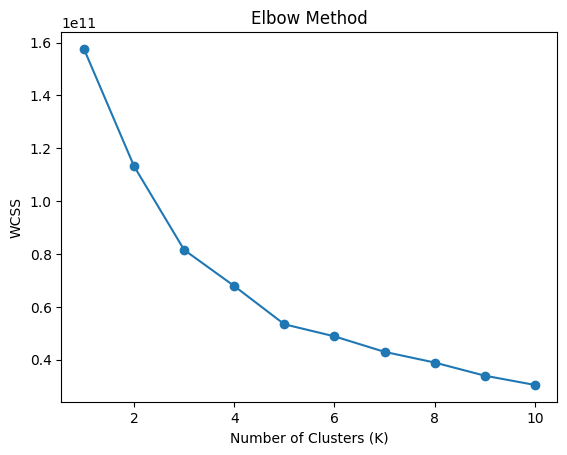

In [20]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


In [29]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=0)

In [30]:
y_kmeans=kmeans.fit_predict(X)

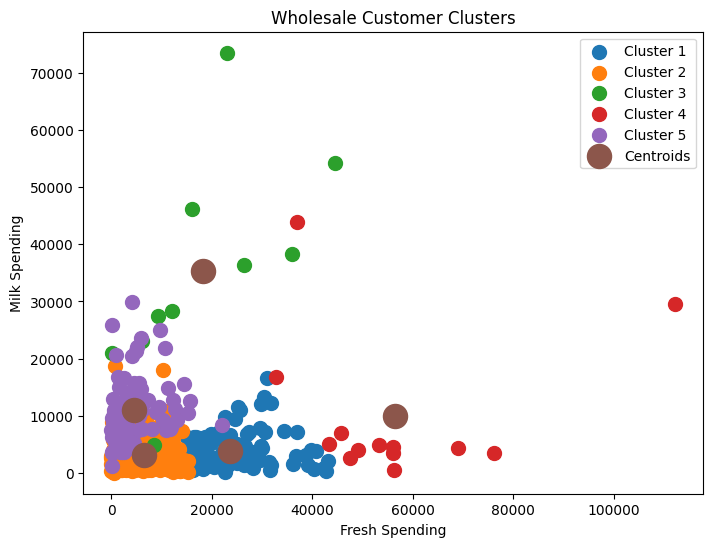

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],
            s=100, label='Cluster 1')

plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1],
            s=100, label='Cluster 2')

plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1],
            s=100, label='Cluster 3')

plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1],
            s=100, label='Cluster 4')

plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1],
            s=100, label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, label='Centroids')

plt.title('Wholesale Customer Clusters')
plt.xlabel('Fresh Spending')
plt.ylabel('Milk Spending')
plt.legend()
plt.show()
